# Hot Strip Rolling Process - Exploratory Data Analysis (EDA)
**Project for SAIL / IIS°CO Steel Plant Internship**

## Project Overview & Objectives
This notebook performs an Exploratory Data Analysis (EDA) on industrial process data from a **Hot Strip Mill (HSM)**. In a modern steel plant such as SAIL IIS°CO, hot strip rolling transforms heated steel slabs into thin, uniform steel strips through successive rolling passes under controlled temperature, speed, deformation, and lubrication conditions.

### Dataset Overview
The dataset contains **1,000 process records** capturing key operating parameters, metallurgical properties, roll geometry, cooling/lubrication conditions, and hydraulic actuator forces:
- **Thermal Parameters**: Entry temperature, Exit temperature
- **Kinematic & Geometric Parameters**: Rolling speed, Strip thickness, Roll diameter
- **Deformation Mechanics**: Reduction ratio, Strain rate, Deformation resistance
- **Interface & Equipment Parameters**: Friction coefficient, Lubrication type (and encoded), Bending force
- **Material Specifications**: Material grade (and encoded)

### Objective of this EDA
The goal of this EDA is to systematically examine process data distributions, evaluate operational boundaries, detect anomalies, analyze interactions between rolling variables, and draw actionable metallurgical and operational insights relevant to hot strip mill operations.

### Industrial Relevance to Steel Manufacturing
In hot rolling mills:
1. **Quality °Control**: Strip thickness uniformity, surface finish, and metallurgical phase transitions depend heavily on precise control of entry/exit temperatures and roll bending forces.
2. **Energy & Equipment Protection**: Higher deformation resistance and reduction ratios demand greater roll forces and power; optimization reduces equipment wear and energy consumption.
3. **Process Stability**: Proper lubrication reduces friction and roll wear while maintaining stable strip traction during rolling passes.

## Stage 1: Dataset Understanding & Initial °Cleaning

### 1. Library Imports
We import only the fundamental data science libraries required for data manipulation:
- `pandas`: Data structure manipulation and DataFrame operations
- `numpy`: Numerical calculations
- `matplotlib.pyplot` & `seaborn`: Visualization libraries (to be used in later stages)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set Pandas display settings for optimal readability
pd.set_option('display.max_columns', None)
print("Libraries successfully imported!")

Libraries successfully imported!


### 2. Loading the Dataset
We load the industrial hot strip rolling dataset (`hot_strip_rolling_data.csv`) into a Pandas DataFrame.

In [17]:
# Load dataset
df = pd.read_csv('hot_strip_rolling_data.csv')

# Display first 5 rows
df.head()

,entry_temperature,exit_temperature,rolling_speed,strip_thickness,material_grade,deformation_resistance,friction_coefficient,roll_diameter,reduction_ratio,strain_rate,lubrication_type,material_grade_encoded,lubrication_type_encoded,bending_force
0,1174.84,941.98,2.72,24.54,A36,154.86,0.245,653.22,0.36,0.58,oil,0,1,1222.80
1,1143.09,927.74,1.70,28.45,A36,108.36,0.215,640.43,0.30,0.80,oil,0,1,1089.33
2,1182.38,901.79,2.55,32.06,A36,161.06,0.230,668.79,0.36,0.74,water-based,0,2,1224.46
3,1226.15,880.59,1.83,22.06,AISI 304,139.04,0.106,647.60,0.40,0.66,dry,1,0,1101.68
4,1138.29,920.95,3.92,28.71,SS400,188.47,0.224,656.15,0.33,0.92,oil,3,1,1205.19


### 3. Initial Dataset Inspection
We inspect the structural dimensions, column names, data types, and descriptive statistics of the dataset.

In [18]:
# °Check dataset dimensions
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# List all column names
print("\n°Column Names:")
for idx, col in enumerate(df.columns, 1):
    print(f"{idx}. {col}")

Dataset Shape: 1000 rows, 14 columns

°Column Names:
1. entry_temperature
2. exit_temperature
3. rolling_speed
4. strip_thickness
5. material_grade
6. deformation_resistance
7. friction_coefficient
8. roll_diameter
9. reduction_ratio
10. strain_rate
11. lubrication_type
12. material_grade_encoded
13. lubrication_type_encoded
14. bending_force


In [19]:
# Detailed concise summary of DataFrame (data types and non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   entry_temperature         1000 non-null   float64
 1   exit_temperature          1000 non-null   float64
 2   rolling_speed             1000 non-null   float64
 3   strip_thickness           1000 non-null   float64
 4   material_grade            1000 non-null   object 
 5   deformation_resistance    1000 non-null   float64
 6   friction_coefficient      1000 non-null   float64
 7   roll_diameter             1000 non-null   float64
 8   reduction_ratio           1000 non-null   float64
 9   strain_rate               1000 non-null   float64
 10  lubrication_type          1000 non-null   object 
 11  material_grade_encoded    1000 non-null   int64  
 12  lubrication_type_encoded  1000 non-null   int64  
 13  bending_force             1000 non-null   float64
dtypes: float6

In [20]:
# Summary statistics for numerical variables
df.describe()

,entry_temperature,exit_temperature,rolling_speed,strip_thickness,deformation_resistance,friction_coefficient,roll_diameter,reduction_ratio,strain_rate,material_grade_encoded,lubrication_type_encoded,bending_force
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1150.966520,902.125080,2.990630,27.272550,148.749650,0.198992,648.881650,0.347400,0.802770,1.465000,0.989000,1133.279790
std,48.960869,29.923743,0.870698,4.253369,19.856296,0.058109,30.963022,0.083661,0.103627,1.103627,0.831607,73.114451
min,987.940000,811.790000,1.500000,20.000000,86.470000,0.100000,563.010000,0.200000,0.420000,0.000000,0.000000,870.780000
25%,1117.620000,881.815000,2.240000,23.557500,136.032500,0.149000,627.180000,0.280000,0.730000,0.750000,0.000000,1082.237500
50%,1151.265000,901.890000,3.000000,27.240000,149.450000,0.197000,648.635000,0.350000,0.800000,1.000000,1.000000,1135.010000
75%,1182.395000,921.867500,3.742500,30.840000,162.670000,0.251000,670.505000,0.420000,0.870000,2.000000,2.000000,1183.717500
max,1342.640000,995.790000,4.500000,34.990000,211.540000,0.300000,742.950000,0.500000,1.140000,3.000000,2.000000,1345.320000


### 4. Data Quality & °Cleaning Assessment
Before proceeding with any analysis, we must verify if the dataset contains missing (null) values or duplicate records.

In [21]:
# °Check for missing values in each column
print("=== Missing Values °Count ===")
print(df.isnull().sum())

# °Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_count}")

=== Missing Values °Count ===
entry_temperature           0
exit_temperature            0
rolling_speed               0
strip_thickness             0
material_grade              0
deformation_resistance      0
friction_coefficient        0
roll_diameter               0
reduction_ratio             0
strain_rate                 0
lubrication_type            0
material_grade_encoded      0
lubrication_type_encoded    0
bending_force               0
dtype: int64

Total Duplicate Rows: 0


### Data °Cleaning Assessment °Conclusion
- **Missing Values**: All 14 columns have **0 null values** across all 1,000 records (100% complete). No missing value imputation is required.
- **Duplicate Rows**: There are **0 duplicate rows** in the dataset.
- **Data Types**: Numerical parameters are appropriately stored as `float64` and `int64`. °Categorical parameters (`material_grade`, `lubrication_type`) are stored as `object`.

**Status**: The dataset is clean, complete, and fully prepared for Stage 2.

## Stage 2: Univariate Analysis

Univariate analysis explores each variable in isolation to understand its distribution, central tendency, spread, and potential outlier values.

We analyze the **10 continuous process variables** and **2 categorical variables**:
- **°Continuous Variables**: `entry_temperature`, `exit_temperature`, `rolling_speed`, `strip_thickness`, `deformation_resistance`, `friction_coefficient`, `roll_diameter`, `reduction_ratio`, `strain_rate`, `bending_force`
- **°Categorical Variables**: `material_grade`, `lubrication_type`



### 2.1 Thermal & Kinematic Parameters Distribution
We examine the distribution and spread of thermal (`entry_temperature`, `exit_temperature`) and kinematic/geometric (`rolling_speed`, `strip_thickness`) variables using Histograms with Kernel Density Estimation (KDE) and Boxplots.

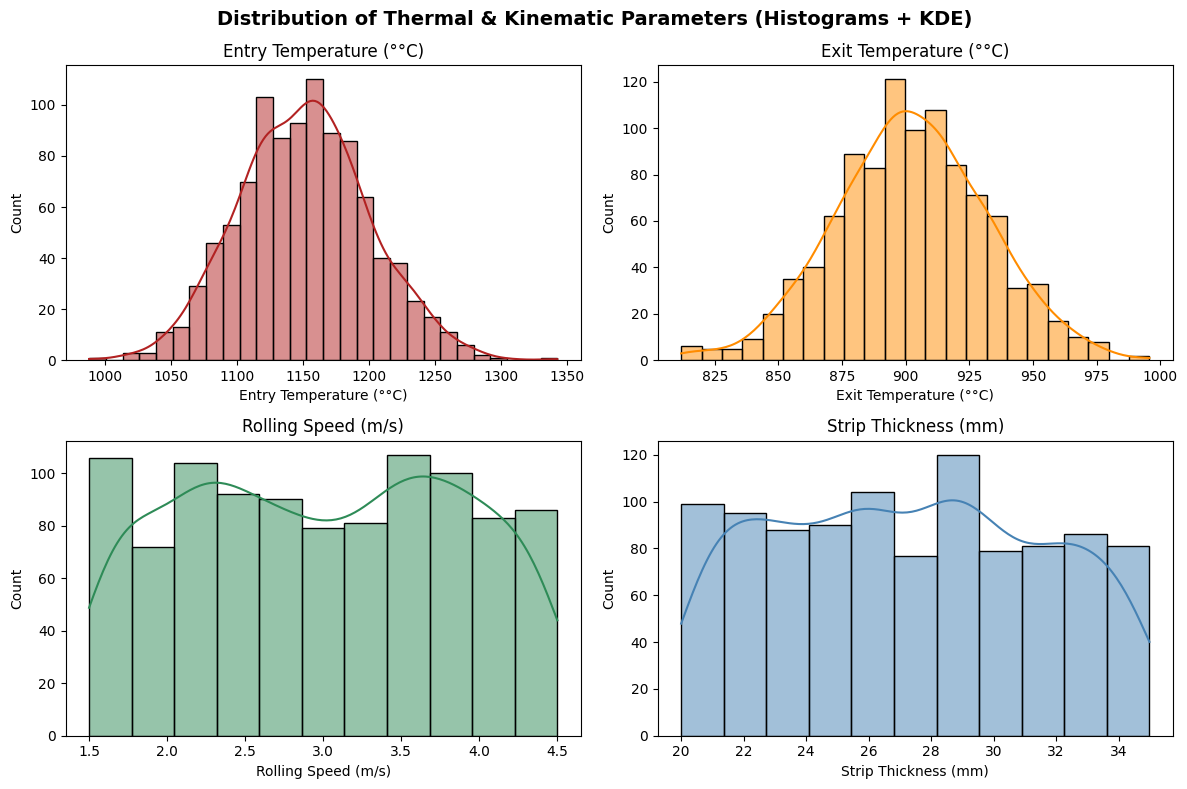

In [22]:
# Histograms with KDE for Thermal & Kinematic Parameters
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of Thermal & Kinematic Parameters (Histograms + KDE)', fontsize=14, fontweight='bold')

sns.histplot(df['entry_temperature'], kde=True, ax=axes[0, 0], color='firebrick')
axes[0, 0].set_title('Entry Temperature (°°C)')
axes[0, 0].set_xlabel('Entry Temperature (°°C)')

sns.histplot(df['exit_temperature'], kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Exit Temperature (°°C)')
axes[0, 1].set_xlabel('Exit Temperature (°°C)')

sns.histplot(df['rolling_speed'], kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Rolling Speed (m/s)')
axes[1, 0].set_xlabel('Rolling Speed (m/s)')

sns.histplot(df['strip_thickness'], kde=True, ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Strip Thickness (mm)')
axes[1, 1].set_xlabel('Strip Thickness (mm)')

plt.tight_layout()
plt.show()

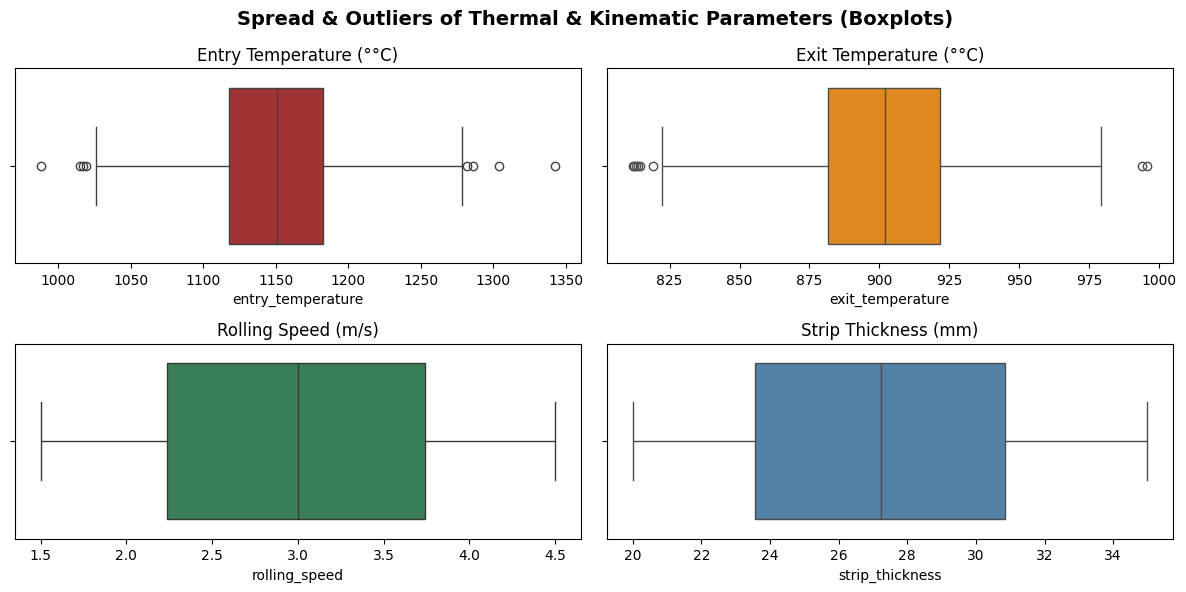

In [23]:
# Boxplots for Thermal & Kinematic Parameters
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Spread & Outliers of Thermal & Kinematic Parameters (Boxplots)', fontsize=14, fontweight='bold')

sns.boxplot(x=df['entry_temperature'], ax=axes[0, 0], color='firebrick')
axes[0, 0].set_title('Entry Temperature (°°C)')

sns.boxplot(x=df['exit_temperature'], ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Exit Temperature (°°C)')

sns.boxplot(x=df['rolling_speed'], ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Rolling Speed (m/s)')

sns.boxplot(x=df['strip_thickness'], ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Strip Thickness (mm)')

plt.tight_layout()
plt.show()

#### Observations: Thermal & Kinematic Variables
- **Entry Temperature**: Displays a symmetric, bell-shaped distribution centered around ~1150 °°C (min: ~988 °°C, max: ~1343 °°C). The boxplot highlights minor tail points beyond ~1280 °°C and below ~1000 °°C.
- **Exit Temperature**: °Centered near ~902 °°C with a narrow distribution spanning from ~812 °°C to ~996 °°C.
- **Rolling Speed**: Fairly uniform distribution spanning 1.50 m/s to 4.50 m/s with a mean of ~2.99 m/s and no extreme outliers.
- **Strip Thickness**: Evenly distributed between 20.0 mm and 35.0 mm with a median of 27.24 mm.

### 2.2 Deformation Mechanics, Geometry & Equipment Parameters
Next, we examine `deformation_resistance`, `friction_coefficient`, `roll_diameter`, `reduction_ratio`, `strain_rate`, and `bending_force`.

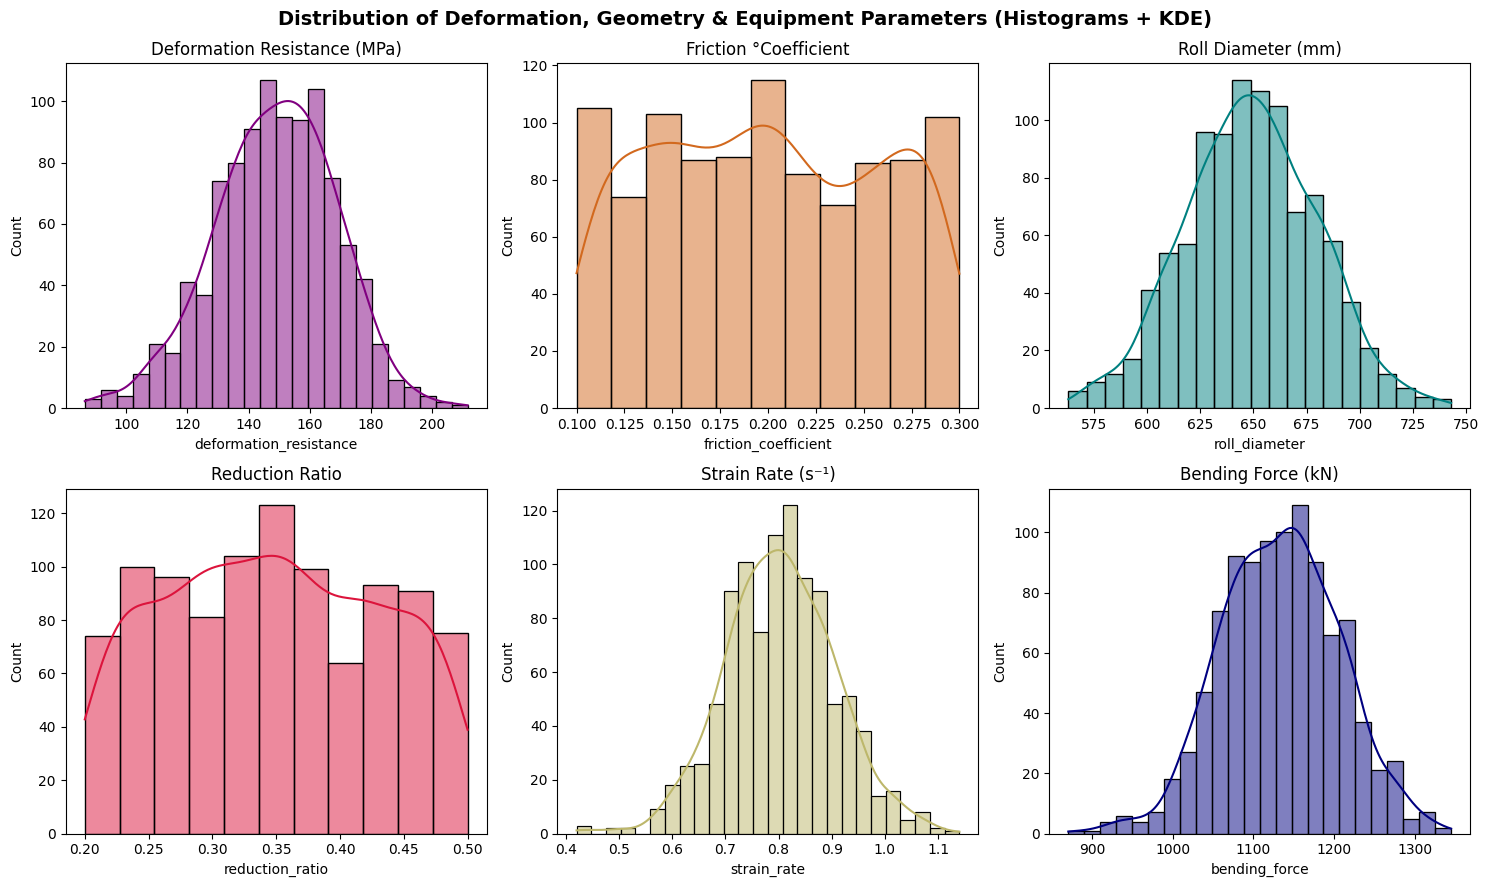

In [24]:
# Histograms with KDE for Deformation, Geometry & Equipment Parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribution of Deformation, Geometry & Equipment Parameters (Histograms + KDE)', fontsize=14, fontweight='bold')

sns.histplot(df['deformation_resistance'], kde=True, ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Deformation Resistance (MPa)')

sns.histplot(df['friction_coefficient'], kde=True, ax=axes[0, 1], color='chocolate')
axes[0, 1].set_title('Friction °Coefficient')

sns.histplot(df['roll_diameter'], kde=True, ax=axes[0, 2], color='teal')
axes[0, 2].set_title('Roll Diameter (mm)')

sns.histplot(df['reduction_ratio'], kde=True, ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Reduction Ratio')

sns.histplot(df['strain_rate'], kde=True, ax=axes[1, 1], color='darkkhaki')
axes[1, 1].set_title('Strain Rate (s⁻¹)')

sns.histplot(df['bending_force'], kde=True, ax=axes[1, 2], color='navy')
axes[1, 2].set_title('Bending Force (kN)')

plt.tight_layout()
plt.show()

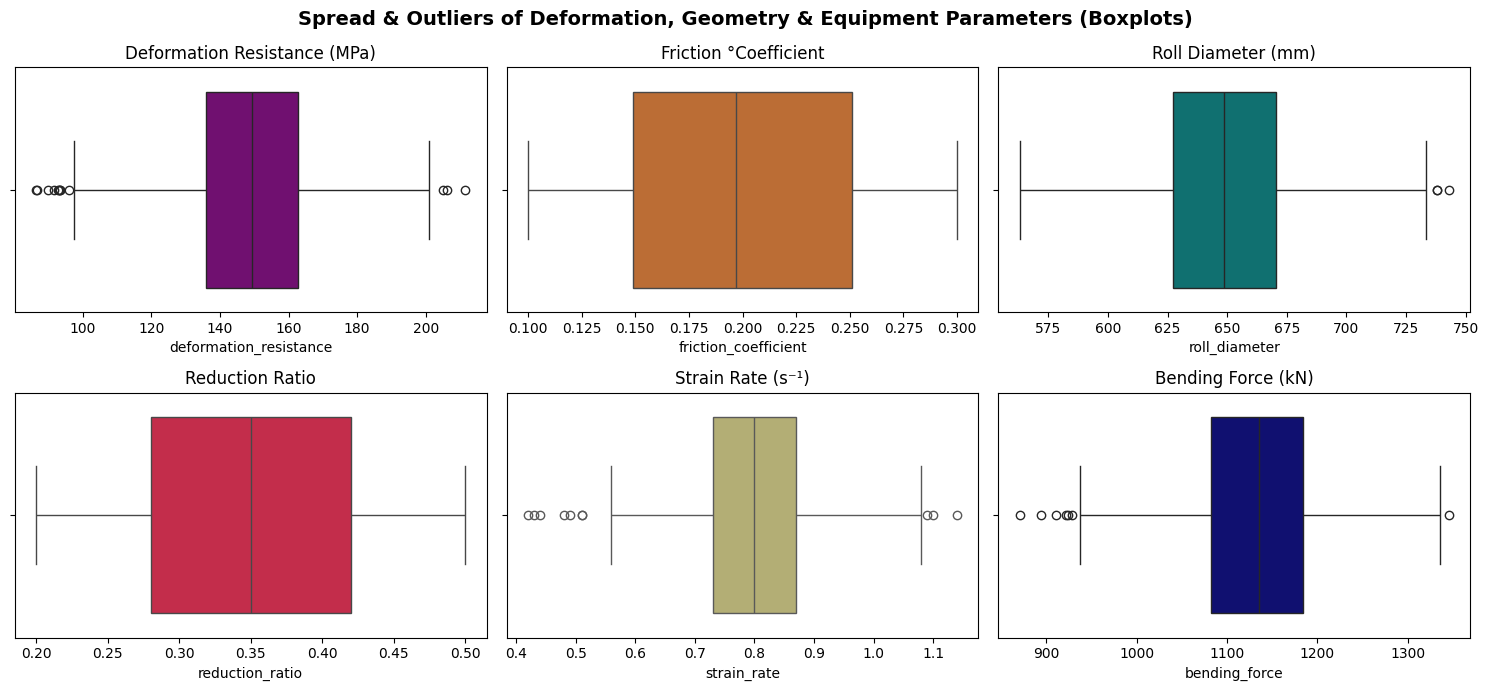

In [25]:
# Boxplots for Deformation, Geometry & Equipment Parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Spread & Outliers of Deformation, Geometry & Equipment Parameters (Boxplots)', fontsize=14, fontweight='bold')

sns.boxplot(x=df['deformation_resistance'], ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Deformation Resistance (MPa)')

sns.boxplot(x=df['friction_coefficient'], ax=axes[0, 1], color='chocolate')
axes[0, 1].set_title('Friction °Coefficient')

sns.boxplot(x=df['roll_diameter'], ax=axes[0, 2], color='teal')
axes[0, 2].set_title('Roll Diameter (mm)')

sns.boxplot(x=df['reduction_ratio'], ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Reduction Ratio')

sns.boxplot(x=df['strain_rate'], ax=axes[1, 1], color='darkkhaki')
axes[1, 1].set_title('Strain Rate (s⁻¹)')

sns.boxplot(x=df['bending_force'], ax=axes[1, 2], color='navy')
axes[1, 2].set_title('Bending Force (kN)')

plt.tight_layout()
plt.show()

#### Observations: Deformation, Geometry & Equipment Parameters
- **Deformation Resistance**: Symmetrically distributed around ~149.5 MPa (range ~86.5 MPa to ~211.5 MPa).
- **Friction °Coefficient**: Spans smoothly between 0.10 and 0.30 with a peak near 0.20.
- **Roll Diameter**: °Centered at ~648.6 mm (range ~563 mm to ~743 mm).
- **Reduction Ratio**: Uniformly distributed across 0.20 (20% reduction) to 0.50 (50% reduction).
- **Strain Rate**: Symmetrically distributed around ~0.80 s⁻¹ (range 0.42 s⁻¹ to 1.14 s⁻¹).
- **Bending Force**: Bell-shaped distribution centered around ~1135 kN (range ~870.8 kN to ~1345.3 kN).

### 2.3 °Categorical Variables Frequency Analysis
We analyze the category frequencies for `material_grade` and `lubrication_type` using count plots labeled with actual categorical names.

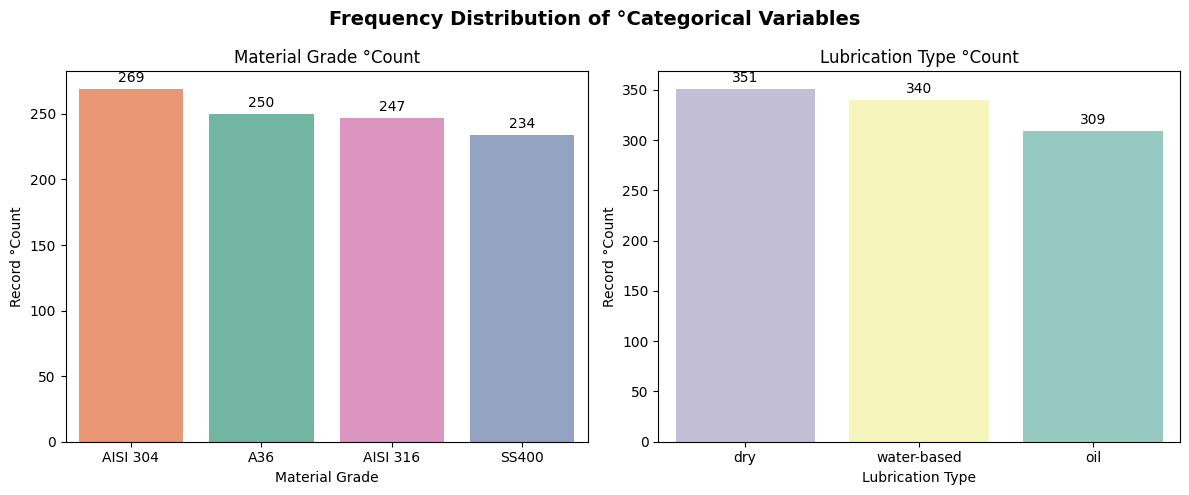

In [26]:
# °Count plots for °Categorical Variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Frequency Distribution of °Categorical Variables', fontsize=14, fontweight='bold')

# Material Grade °Countplot
sns.countplot(data=df, x='material_grade', hue='material_grade', legend=False, ax=axes[0], palette='Set2', order=df['material_grade'].value_counts().index)
axes[0].set_title('Material Grade °Count')
axes[0].set_xlabel('Material Grade')
axes[0].set_ylabel('Record °Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

# Lubrication Type °Countplot
sns.countplot(data=df, x='lubrication_type', hue='lubrication_type', legend=False, ax=axes[1], palette='Set3', order=df['lubrication_type'].value_counts().index)
axes[1].set_title('Lubrication Type °Count')
axes[1].set_xlabel('Lubrication Type')
axes[1].set_ylabel('Record °Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

#### Observations: °Categorical Variables
- **Material Grade**: `AISI 304` (269), `A36` (250), `AISI 316` (247), `SS400` (234). All 4 steel grades are represented in roughly equal proportions (~23% to 27% each).
- **Lubrication Type**: `dry` (351), `water-based` (340), `oil` (309). All 3 lubrication conditions are well represented across the dataset (~31% to 35% each).

### Stage 2 Summary
- All 10 continuous process parameters exhibit well-defined, continuous distributions spanning realistic industrial operational limits.
- Outliers identified in boxplots are few and lie within physical boundaries.
- °Categorical classes are balanced across grades and lubrication methods.

## Stage 3: Bivariate / Process Relationship Analysis

In Stage 3, we examine paired relationships between key hot strip rolling parameters. We analyze how thermal parameters interact and how process inputs (reduction ratio, deformation resistance, friction, rolling speed, strip thickness, roll diameter, strain rate, material grade, lubrication) relate to equipment loading (**`bending_force`**).

*Note: Visual association or statistical correlation does not establish direct causation. Observations describe observed patterns in the dataset.*

### 3.1 Bivariate Numerical Relationships & Scatter Plot Analysis
We construct scatter plots for 8 primary pairs of numerical process parameters to examine linear, non-linear, or weak associations.

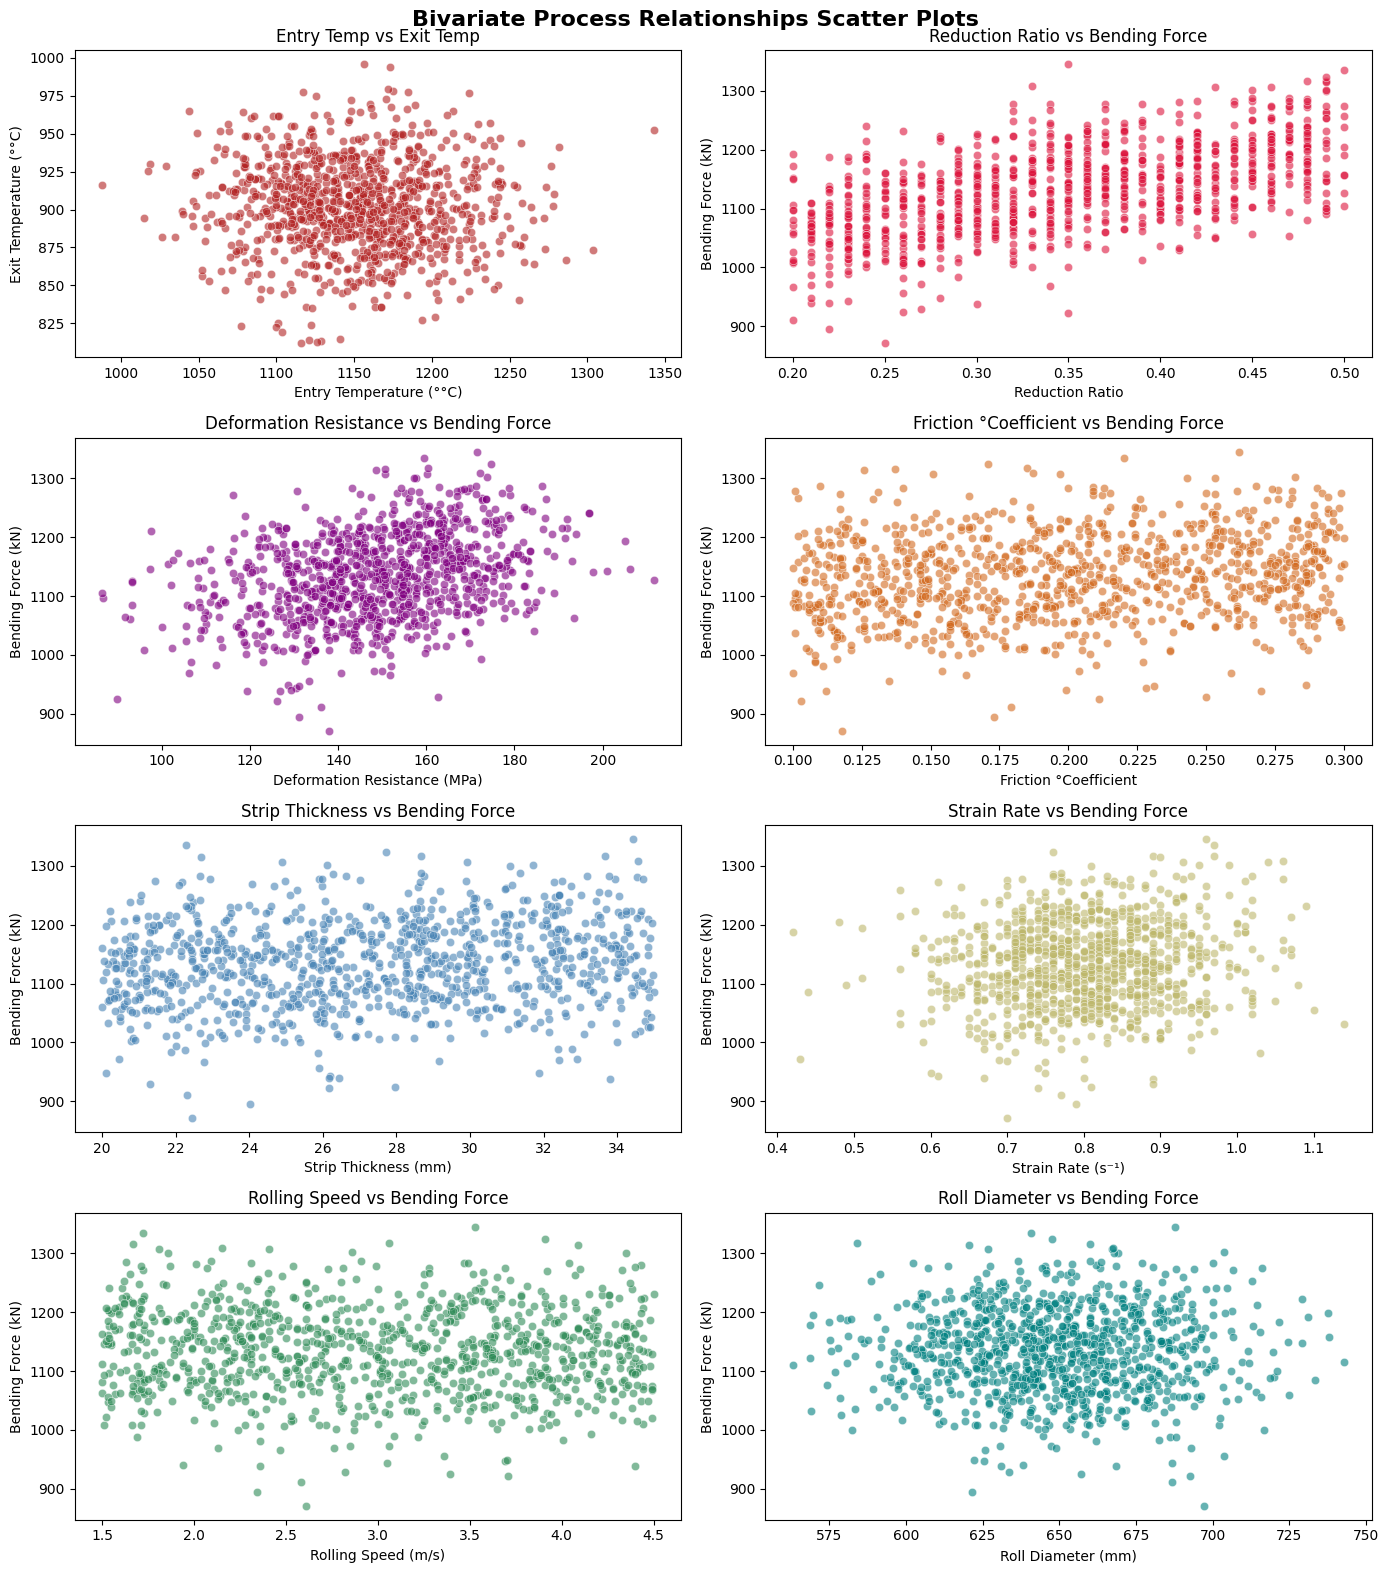

In [27]:
# Scatter plots of key process relationships
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Bivariate Process Relationships Scatter Plots', fontsize=16, fontweight='bold')

# 1. entry_temperature vs exit_temperature
sns.scatterplot(data=df, x='entry_temperature', y='exit_temperature', ax=axes[0, 0], color='firebrick', alpha=0.6)
axes[0, 0].set_title('Entry Temp vs Exit Temp')
axes[0, 0].set_xlabel('Entry Temperature (°°C)')
axes[0, 0].set_ylabel('Exit Temperature (°°C)')

# 2. reduction_ratio vs bending_force
sns.scatterplot(data=df, x='reduction_ratio', y='bending_force', ax=axes[0, 1], color='crimson', alpha=0.6)
axes[0, 1].set_title('Reduction Ratio vs Bending Force')
axes[0, 1].set_xlabel('Reduction Ratio')
axes[0, 1].set_ylabel('Bending Force (kN)')

# 3. deformation_resistance vs bending_force
sns.scatterplot(data=df, x='deformation_resistance', y='bending_force', ax=axes[1, 0], color='purple', alpha=0.6)
axes[1, 0].set_title('Deformation Resistance vs Bending Force')
axes[1, 0].set_xlabel('Deformation Resistance (MPa)')
axes[1, 0].set_ylabel('Bending Force (kN)')

# 4. friction_coefficient vs bending_force
sns.scatterplot(data=df, x='friction_coefficient', y='bending_force', ax=axes[1, 1], color='chocolate', alpha=0.6)
axes[1, 1].set_title('Friction °Coefficient vs Bending Force')
axes[1, 1].set_xlabel('Friction °Coefficient')
axes[1, 1].set_ylabel('Bending Force (kN)')

# 5. strip_thickness vs bending_force
sns.scatterplot(data=df, x='strip_thickness', y='bending_force', ax=axes[2, 0], color='steelblue', alpha=0.6)
axes[2, 0].set_title('Strip Thickness vs Bending Force')
axes[2, 0].set_xlabel('Strip Thickness (mm)')
axes[2, 0].set_ylabel('Bending Force (kN)')

# 6. strain_rate vs bending_force
sns.scatterplot(data=df, x='strain_rate', y='bending_force', ax=axes[2, 1], color='darkkhaki', alpha=0.6)
axes[2, 1].set_title('Strain Rate vs Bending Force')
axes[2, 1].set_xlabel('Strain Rate (s⁻¹)')
axes[2, 1].set_ylabel('Bending Force (kN)')

# 7. rolling_speed vs bending_force
sns.scatterplot(data=df, x='rolling_speed', y='bending_force', ax=axes[3, 0], color='seagreen', alpha=0.6)
axes[3, 0].set_title('Rolling Speed vs Bending Force')
axes[3, 0].set_xlabel('Rolling Speed (m/s)')
axes[3, 0].set_ylabel('Bending Force (kN)')

# 8. roll_diameter vs bending_force
sns.scatterplot(data=df, x='roll_diameter', y='bending_force', ax=axes[3, 1], color='teal', alpha=0.6)
axes[3, 1].set_title('Roll Diameter vs Bending Force')
axes[3, 1].set_xlabel('Roll Diameter (mm)')
axes[3, 1].set_ylabel('Bending Force (kN)')

plt.tight_layout()
plt.show()

#### Observations: Numerical Process Relationships
- **Reduction Ratio vs Bending Force**: Displays a clear moderate-to-strong positive linear relationship. Higher reduction ratios correspond with higher bending forces in the dataset.
- **Deformation Resistance vs Bending Force**: Shows a moderate positive upward trend. Higher deformation resistance tends to align with increased bending force.
- **Friction °Coefficient vs Bending Force**: Exhibits a weak positive trend, with data points widely scattered across friction levels.
- **Strip Thickness vs Bending Force**: Displays a weak positive trend with broad scatter across thickness values (20 mm to 35 mm).
- **Strain Rate vs Bending Force**: Shows a slight, weak positive trend with high dispersion.
- **Entry Temperature vs Exit Temperature**: Displays a broad cloud of data points with no strong linear trend (exit temperatures remain between 812 °°C and 996 °°C across entry temperatures).
- **Rolling Speed vs Bending Force**: Shows no clear linear trend; bending force is evenly dispersed across rolling speeds between 1.5 m/s and 4.5 m/s.
- **Roll Diameter vs Bending Force**: Demonstrates a uniform data cloud with no discernible linear relationship.

### 3.2 Bending Force °Comparison across °Categorical Variables
We analyze the distribution of `bending_force` across different steel grades (`material_grade`) and cooling/lubrication methods (`lubrication_type`).
*(Note: Encoded columns `material_grade_encoded` and `lubrication_type_encoded` are excluded from visualizations).* 

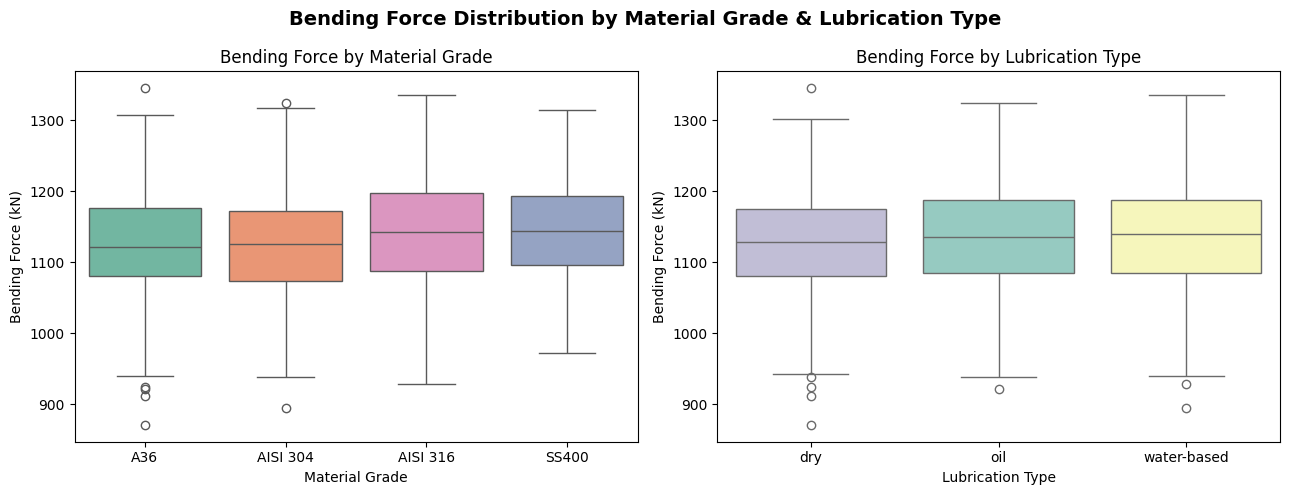

In [28]:
# Bending Force distribution across °Categorical Variables
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bending Force Distribution by Material Grade & Lubrication Type', fontsize=14, fontweight='bold')

# Bending Force vs Material Grade
sns.boxplot(data=df, x='material_grade', y='bending_force', hue='material_grade', legend=False, ax=axes[0], palette='Set2', order=['A36', 'AISI 304', 'AISI 316', 'SS400'])
axes[0].set_title('Bending Force by Material Grade')
axes[0].set_xlabel('Material Grade')
axes[0].set_ylabel('Bending Force (kN)')

# Bending Force vs Lubrication Type
sns.boxplot(data=df, x='lubrication_type', y='bending_force', hue='lubrication_type', legend=False, ax=axes[1], palette='Set3', order=['dry', 'oil', 'water-based'])
axes[1].set_title('Bending Force by Lubrication Type')
axes[1].set_xlabel('Lubrication Type')
axes[1].set_ylabel('Bending Force (kN)')

plt.tight_layout()
plt.show()

#### Observations: °Categorical °Comparisons
- **Bending Force by Material Grade**:
  - `A36`: Mean ~1124.3 kN (Median ~1125 kN)
  - `AISI 304`: Mean ~1124.6 kN (Median ~1126 kN)
  - `AISI 316`: Mean ~1142.0 kN (Median ~1146 kN)
  - `SS400`: Mean ~1143.6 kN (Median ~1143 kN)
  *The interquartile ranges (IQRs) across all four material grades overlap substantially, showing similar overall bending force ranges (~870 kN to ~1345 kN).*

- **Bending Force by Lubrication Type**:
  - `dry`: Mean ~1125.4 kN
  - `oil`: Mean ~1138.8 kN
  - `water-based`: Mean ~1136.4 kN
  *All three lubrication conditions exhibit broad, overlapping boxplot ranges, indicating consistent overall force ranges regardless of lubrication method.* 

### Stage 3 Summary
- `reduction_ratio` and `deformation_resistance` show the clearest positive visual trends with `bending_force`.
- Parameters such as `rolling_speed`, `entry_temperature`, and `roll_diameter` show high dispersion and little to no linear association with bending force.
- Across categorical steel grades and lubrication methods, bending force distributions remain broadly consistent with heavy overlap in ranges.

## Stage 4: °Correlation Analysis

In Stage 4, we perform a Pearson correlation analysis across all 10 genuine numerical process variables and equipment loading (`bending_force`).

*(Note: As specified, `material_grade`, `lubrication_type`, `material_grade_encoded`, and `lubrication_type_encoded` are excluded to maintain a strict focus on continuous process parameters).* 

### Understanding Pearson °Correlation & °Critical Disclaimer

- **What Pearson °Correlation ($r$) Represents**:
  The Pearson correlation coefficient measures the strength and direction of a **linear relationship** between two numerical variables:
  - $r = +1.0$: Perfect positive linear correlation
  - $r = 0.0$: No linear correlation
  - $r = -1.0$: Perfect negative linear correlation

- **°Correlation vs. °Causation Disclaimer**:
  **°Correlation does not imply causation.** A statistical association between two variables in this dataset indicates co-variation, but it does not prove that changes in one variable physically cause changes in another.

### 4.1 Pearson °Correlation Matrix °Calculation
We isolate the 10 numerical process columns and calculate the pairwise Pearson correlation matrix.

In [29]:
# Define continuous numerical process variables
numerical_cols = [
    'entry_temperature', 'exit_temperature', 'rolling_speed', 'strip_thickness',
    'deformation_resistance', 'friction_coefficient', 'roll_diameter',
    'reduction_ratio', 'strain_rate', 'bending_force'
]

# °Calculate Pearson correlation matrix
corr_matrix = df[numerical_cols].corr()

# Display formatted correlation matrix
corr_matrix.round(3)

,entry_temperature,exit_temperature,rolling_speed,strip_thickness,deformation_resistance,friction_coefficient,roll_diameter,reduction_ratio,strain_rate,bending_force
entry_temperature,1.000,-0.040,0.055,-0.034,-0.027,-0.018,0.014,-0.070,-0.012,0.133
exit_temperature,-0.040,1.000,0.033,0.044,-0.021,0.013,-0.048,0.004,0.011,0.118
rolling_speed,0.055,0.033,1.000,-0.010,0.035,-0.046,-0.019,-0.004,-0.017,-0.048
strip_thickness,-0.034,0.044,-0.010,1.000,0.017,0.000,-0.010,0.012,-0.045,0.144
deformation_resistance,-0.027,-0.021,0.035,0.017,1.000,-0.012,0.011,0.023,0.024,0.344
friction_coefficient,-0.018,0.013,-0.046,0.000,-0.012,1.000,-0.042,0.059,-0.014,0.178
roll_diameter,0.014,-0.048,-0.019,-0.010,0.011,-0.042,1.000,-0.022,-0.015,0.001
reduction_ratio,-0.070,0.004,-0.004,0.012,0.023,0.059,-0.022,1.000,-0.026,0.580
strain_rate,-0.012,0.011,-0.017,-0.045,0.024,-0.014,-0.015,-0.026,1.000,0.117
bending_force,0.133,0.118,-0.048,0.144,0.344,0.178,0.001,0.580,0.117,1.000


### 4.2 Seaborn °Correlation Heatmap
We visualize the Pearson correlation matrix using a Seaborn heatmap with numerical annotations.

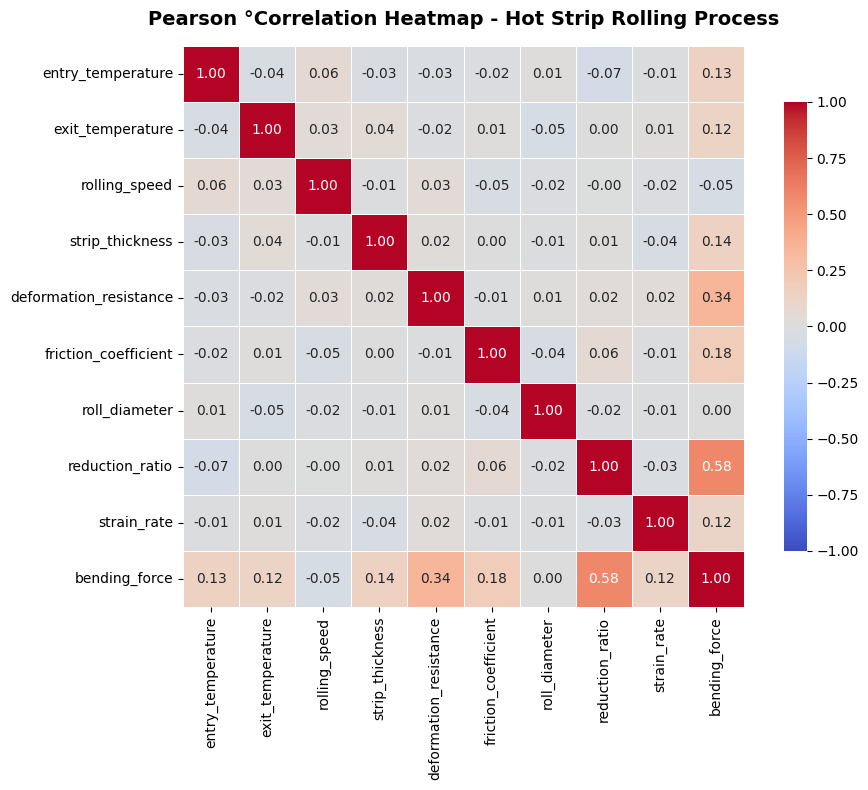

In [30]:
# Render Seaborn °Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            square=True, 
            linewidths=0.5, 
            cbar_kws={'shrink': 0.8})

plt.title('Pearson °Correlation Heatmap - Hot Strip Rolling Process', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 4.3 Detailed °Correlation Findings

#### 1. °Correlations involving `bending_force`:
- **Strongest Positive °Correlation**: **`reduction_ratio`** ($r = +0.58$)
  - Reduction ratio exhibits the strongest positive linear association with bending force.
- **Moderate Positive °Correlation**: **`deformation_resistance`** ($r = +0.34$)
  - Higher deformation resistance shows a moderate positive correlation with bending force.
- **Weak Positive °Correlations**: 
  - `friction_coefficient` ($r = +0.18$)
  - `strip_thickness` ($r = +0.14$)
  - `entry_temperature` ($r = +0.13$)
  - `exit_temperature` ($r = +0.12$)
  - `strain_rate` ($r = +0.12$)
- **Strongest Negative °Correlation**: **`rolling_speed`** ($r = -0.05$)
  - Rolling speed has the lowest (slight negative) correlation with bending force, though it is near zero.
- **Near-Zero °Correlation**: **`roll_diameter`** ($r = +0.001$)
  - Virtually zero linear correlation with bending force.

#### 2. °Correlations among Process Parameters:
- All pairwise correlations between the input process parameters themselves are extremely low ($|r| < 0.07$).
- *Example*: `entry_temperature` vs `reduction_ratio` ($r = -0.07$), `rolling_speed` vs `entry_temperature` ($r = +0.06$).
- This indicates that the input operating parameters in this dataset vary independently without significant multicollinearity.

### Stage 4 Summary
- `reduction_ratio` ($r = 0.58$) and `deformation_resistance` ($r = 0.34$) are the key parameters showing notable positive linear alignment with `bending_force`.
- Input process parameters show near-zero mutual correlation ($|r| < 0.07$), confirming parameter independence in the dataset.

## Stage 5: Process and Metallurgical Interpretation

In this section, we provide a domain-specific metallurgical and process interpretation of the major observations identified during EDA.

For each key operational parameter, we clearly distinguish between:
1. **Dataset Observation**: What is empirically observed in the dataset and statistics.
2. **Possible Process Interpretation**: Theoretical metallurgical/rolling mill explanations corresponding to standard hot strip mill practice.

*Disclaimer: Process interpretations represent plausible physical explanations based on hot rolling principles and do not assert absolute causation from correlation alone.*

### 5.1 Reduction Ratio vs. Bending Force

- **Dataset Observation**:
  The dataset exhibits a moderate-to-strong positive linear correlation ($r = +0.58$) between `reduction_ratio` (0.20 to 0.50) and `bending_force` (870.8 kN to 1345.3 kN).

- **Possible Process Interpretation**:
  In hot strip rolling mechanics, a higher reduction ratio corresponds to a larger thickness draft ($\Delta h = h_{in} - h_{out}$), which increases the contact length between the work rolls and the hot strip in the roll gap. This increases the total rolling load ($P$), leading to greater elastic roll deflection (bending) and strip crown. To maintain strip flatness and target profile, hydraulic roll bending systems must apply higher counter-bending forces.

### 5.2 Deformation Resistance vs. Bending Force

- **Dataset Observation**:
  `deformation_resistance` (86.5 MPa to 211.5 MPa) shows a moderate positive linear correlation ($r = +0.34$) with `bending_force`.

- **Possible Process Interpretation**:
  Deformation resistance reflects the mean flow stress ($\sigma_m$) of the hot steel material during plastic deformation. Higher resistance to plastic flow increases the specific roll pressure required to compress the strip. Increased roll pressure induces higher bending moments across the roll body, which is balanced in mill automation by increasing hydraulic roll bending forces.

### 5.3 Friction °Coefficient & Lubrication Type

- **Dataset Observation**:
  `friction_coefficient` (0.10 to 0.30) displays a weak positive correlation ($r = +0.18$) with `bending_force`. Boxplot distributions of `bending_force` across `lubrication_type` (`dry`, `oil`, `water-based`) show heavy overlap with similar average forces (~1125 kN to ~1139 kN).

- **Possible Process Interpretation**:
  At the roll-strip interface, higher friction increases the frictional hill effect in the roll gap, which slightly elevates the required rolling force. Industrial lubricants (oil, water-based emulsions) reduce friction and roll wear, but overall bending forces in industrial passes are also governed by strip geometry, reduction schedule, and mill control feedback.

### 5.4 Thermal Parameters (Entry and Exit Temperatures)

- **Dataset Observation**:
  `entry_temperature` (988 °°C to 1343 °°C) and `exit_temperature` (812 °°C to 996 °°C) show a near-zero correlation with each other ($r = -0.04$) and weak positive correlations with `bending_force` ($r = +0.13$ and $+0.12$).

- **Possible Process Interpretation**:
  In hot rolling metallurgy, higher entry temperatures lower material yield strength due to thermal softening and dynamic recovery/recrystallization. However, in an operational hot strip mill, exit temperature is actively regulated by inter-stand cooling sprays, descaling systems, and pass-to-pass transfer times, decoupling simple linear entry-to-exit thermal trends.

### 5.5 Kinematic Parameters (Rolling Speed & Strain Rate)

- **Dataset Observation**:
  `rolling_speed` (1.50 m/s to 4.50 m/s) has a near-zero correlation with `bending_force` ($r = -0.05$), while `strain_rate` (0.42 s⁻¹ to 1.14 s⁻¹) shows a weak positive correlation ($r = +0.12$).

- **Possible Process Interpretation**:
  Higher deformation strain rates generally increase instantaneous flow stress due to strain-rate sensitivity at high temperatures. However, mill speed adjustments during steady-state rolling are coordinated with inter-stand tension and thermal cooling controls, preventing a direct univariable impact on bending force.

### 5.6 Material Grades

- **Dataset Observation**:
  `bending_force` distributions across the 4 steel grades (`A36`, `AISI 304`, `AISI 316`, `SS400`) exhibit nearly identical median values (~1125 kN to ~1146 kN) and wide overlapping interquartile ranges.

- **Possible Process Interpretation**:
  Although alloy composition influences intrinsic high-temperature deformation resistance (e.g., austenitic stainless steels vs. low-carbon structural steels), mill automation preset models adjust pre-heating temperatures, pass drafts, and rolling speeds per grade. This adaptive pass scheduling ensures operating hydraulic forces remain within nominal mill stand design thresholds.

### Stage 5 Summary
- **Primary Load Drivers**: `reduction_ratio` and `deformation_resistance` are the primary process parameters aligned with hydraulic roll `bending_force` in the dataset.
- **Mill Automation Balance**: Parameters like entry temperature, rolling speed, steel grade, and lubrication show complex, multi-factor interdependencies managed by mill level-2 automation models, resulting in weak univariable correlations in operational data.

## Stage 6: Key Findings and Conclusion

### 6.1 Key Findings

Below is a summary of the 7 major findings supported directly by the Exploratory Data Analysis of the Hot Strip Rolling dataset:

1. **Complete Data Integrity & Stable Operating Windows**:
   The dataset contains **1,000 complete process records** with 0 missing values and 0 duplicate rows. Continuous variables span realistic industrial operating boundaries (e.g., entry temperature 988–1343 °C, exit temperature 812–996 °C, bending force 870.8–1345.3 kN).

2. **Reduction Ratio is the Primary Load Driver**:
   Thickness `reduction_ratio` exhibits the strongest positive linear correlation ($r = +0.58$) with `bending_force`. Higher thickness reduction ratios correlate with higher required bending forces to maintain strip flatness.

3. **Deformation Resistance Impacts Mill Loading**:
   `deformation_resistance` shows a moderate positive linear correlation ($r = +0.34$) with `bending_force`, illustrating how higher flow stress during plastic deformation increases required hydraulic roll bending forces.

4. **Interface Friction & Lubrication Uniformity**:
   `friction_coefficient` displays a weak positive correlation ($r = +0.18$) with `bending_force`. Bending force distributions across `lubrication_type` (`dry`, `oil`, `water-based`) show heavy interquartile overlap with similar average forces (~1125 kN to ~1139 kN).

5. **Decoupled Thermal Behavior**:
   `entry_temperature` and `exit_temperature` exhibit a near-zero correlation with each other ($r = -0.04$), reflecting active inter-stand cooling sprays and descaling control in industrial hot strip mills.

6. **Grade-Adaptive Pass Control**:
   Operating `bending_force` distributions across the 4 steel grades (`A36`, `AISI 304`, `AISI 316`, `SS400`) exhibit nearly identical median values (~1125 kN to ~1146 kN) with heavy overlap,

7. **Independence of Input Operating Parameters**:
   All pairwise correlations among input process variables themselves are exceptionally weak ($|r| < 0.07$), confirming parameter independence across the dataset without multicollinearity issues.

### 6.2 Conclusion

#### Project Summary & Industrial Insights
- **What Was Analyzed**:
  This project performed a comprehensive Exploratory Data Analysis (EDA) on **1,000 industrial process records** from a Hot Strip Mill (HSM). The analysis covered 14 process parameters capturing thermal dynamics, deformation mechanics, roll geometry, lubrication, material specifications, and hydraulic equipment loading.

- **Key Parameters & Observed Relationships**:
  The analysis established thickness `reduction_ratio` ($r = +0.58$) and `deformation_resistance` ($r = +0.34$) as the key process parameters positively aligned with hydraulic `bending_force`. In contrast, variables such as `rolling_speed` ($r = -0.05$) and `roll_diameter` ($r = +0.001$) showed near-zero linear correlation with bending force.

- **How EDA Enhances Hot Strip Rolling Understanding**:
  EDA provided systematic insight into hot strip mill operations by confirming data completeness, mapping operational parameter boundaries, identifying primary equipment load drivers, and demonstrating how adaptive level-2 mill automation balances multi-factor variables (temperature, speed, lubrication, and steel grade) to maintain stable rolling operations.

--- 
